## TG Data Processing 
- turn .ascii files to .nc files for each station
- verify whether 11 stations in GESLA_laguna_madre have data for calval phase
- quality check and only keep good quality stations 

In [1]:
# Import libraries
import xarray as xr
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from glob import glob
#import swot_ssh_utils as swot
import os
import earthaccess
from dask.distributed import Client
import dask
import pandas as pd

from cartopy import crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import pyplot as plt


import os
import re
from datetime import datetime

## Filtering TG to Laguna Madre

In [2]:
meta_df = pd.read_csv('/home/nsv9/data/GESLA4 GOM/GOMstations_metadata.csv')
meta_df.head()

,file_name,site_name,site_code,latitude,longitude,start_datetime,end_datetime,overall_rec_quality
0,galveston_pier_21-775-usa-uhslc_fd,Galveston_Pier_21,775,29.310,-94.793000,1/1/1904 6:00,2025.0,No obvious issues
1,key_west_fl-242-usa-uhslc_fd,Key_West_FL,242,24.553,-81.808000,1/19/1913 6:00,2025.0,No obvious issues
2,pensacola_fl-762-usa-uhslc_fd,Pensacola_FL,762,30.403,-87.213000,5/1/1923 6:00,2025.0,No obvious issues
3,virginia_key_fl-755-usa-uhslc_fd,Virginia_Key_FL,755,25.732,-80.162000,1/28/1994 16:00,2025.0,No obvious issues
4,galveston_pier_21-8771450-usa-noaa,Galveston_Pier_21,8771450,29.310,-94.793306,1/1/1904 1:00,2025.0,No obvious issues


In [3]:
meta_df['latitude'].min(), meta_df['latitude'].max(), meta_df['longitude'].min(), meta_df['longitude'].max()

(15.75333333, 31.45333333, -97.6288843, -80.034167)

In [4]:
meta_lm = meta_df[(meta_df['latitude'] >= 25.5) & (meta_df['latitude'] <= 27.5) & (meta_df['longitude'] >= -97.6) & (meta_df['longitude'] <= -96)]
#print(meta_lm['file_name'].values)
print(meta_lm['site_name'].values)
len(meta_lm['site_name'].values)


<StringArray>
[                                  'Port_Isabel',
                                'Port_Mansfield',
                                    'Baffin_Bay',
                           'Rincon_Del_San_Jose',
                                 'S_Bird_Island',
                 'South_Padre_Island_Cg_Station',
                           'Spi_Brazos_Santiago',
                            'Realitos_Peninsula',
   'Cameron_Co_Ditch_1_At_Fm_802_Brownsville_Tx',
    'Old_Main_Drain_No_2_At_Sh_4_Brownsville_Tx',
 'Brazos_Santiago_Pass_At_South_Padre_Island_Tx']
Length: 11, dtype: str


11

In [5]:
data_path = '/home/nsv9/data/GESLA_laguna_madre/'
file_name = meta_lm['file_name'].values[4]
print(file_name)

data = pd.read_csv(
        data_path + file_name,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["date", "time", "sea_level", "qc_flag", "use_flag"])

data['datetime'] = pd.to_datetime(data['date'] + ' ' + data['time'], format='%Y/%m/%d %H:%M:%S')
data = data.drop(columns=['date', 'time'])
data

calval_start = pd.Timestamp('2023-04-01')
calval_end = pd.Timestamp('2023-07-04')

data_calval = data[(data['datetime'] >= calval_start) & (data['datetime'] <= calval_end)]
data_calval['use_flag'].value_counts()

s_bird_island-8776139-usa-noaa


use_flag
1    2257
Name: count, dtype: int64

In [6]:
data_path = '/home/nsv9/data/GESLA_laguna_madre/'
file_name = meta_lm['file_name'].values[0]

data = pd.read_csv(
        data_path + file_name,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["date", "time", "sea_level", "qc_flag", "use_flag"])

data['datetime'] = pd.to_datetime(data['date'] + ' ' + data['time'], format='%Y/%m/%d %H:%M:%S')
data = data.drop(columns=['date', 'time'])
data


,sea_level,qc_flag,use_flag,datetime
0,-99.9999,5,0,1944-01-01 01:00:00
1,-99.9999,5,0,1944-01-01 02:00:00
2,-99.9999,5,0,1944-01-01 03:00:00
3,-99.9999,5,0,1944-01-01 04:00:00
4,-99.9999,5,0,1944-01-01 05:00:00
...,...,...,...,...
693979,1.5470,1,1,2025-06-30 19:00:00
693980,1.6010,1,1,2025-06-30 20:00:00
693981,1.5990,1,1,2025-06-30 21:00:00
693982,1.6140,1,1,2025-06-30 22:00:00


In [7]:
# Process all files and filter by time period and data quality
calval_start = pd.Timestamp('2023-04-01')
calval_end = pd.Timestamp('2023-07-04')

valid_stations = {}

for file_name in meta_lm['file_name'].values:
    data = pd.read_csv(
        data_path + file_name,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["date", "time", "sea_level", "qc_flag", "use_flag"])
    
    data['datetime'] = pd.to_datetime(data['date'] + ' ' + data['time'], format='%Y/%m/%d %H:%M:%S')
    data = data.drop(columns=['date', 'time'])
    
    # Filter to calval period
    data_calval = data[(data['datetime'] >= calval_start) & (data['datetime'] <= calval_end)]
    
    # Check invalid points and remove them, include all stations
    if len(data_calval) > 0:
        invalid_points = (data_calval['use_flag'] != 1).sum()
        # Filter to keep only valid points
        data_filtered = data_calval[data_calval['use_flag'] == 1]
        station_name = meta_lm[meta_lm['file_name'] == file_name]['site_name'].values[0]
        valid_stations[station_name] = data_filtered
        print(f"Station: {station_name} (removed {invalid_points} invalid points, kept {len(data_filtered)} points)")

# remove inland stations, not in the lagoon 
invalid_stations = ['Old_Main_Drain_No_2_At_Sh_4_Brownsville_Tx', 'Cameron_Co_Ditch_1_At_Fm_802_Brownsville_Tx']
for station in invalid_stations:
    if station in valid_stations:
        del valid_stations[station]
        print(f"Removed inland station: {station}")

print(f"\nTotal valid stations: {len(valid_stations)}")


Station: Port_Isabel (removed 0 invalid points, kept 2257 points)
Station: Port_Mansfield (removed 0 invalid points, kept 2257 points)
Station: Baffin_Bay (removed 31 invalid points, kept 2226 points)
Station: Rincon_Del_San_Jose (removed 4 invalid points, kept 2253 points)
Station: S_Bird_Island (removed 0 invalid points, kept 2257 points)
Station: South_Padre_Island_Cg_Station (removed 1 invalid points, kept 2256 points)
Station: Spi_Brazos_Santiago (removed 5 invalid points, kept 2252 points)
Station: Realitos_Peninsula (removed 4 invalid points, kept 2253 points)
Station: Cameron_Co_Ditch_1_At_Fm_802_Brownsville_Tx (removed 0 invalid points, kept 2257 points)
Station: Old_Main_Drain_No_2_At_Sh_4_Brownsville_Tx (removed 0 invalid points, kept 2257 points)
Removed inland station: Old_Main_Drain_No_2_At_Sh_4_Brownsville_Tx
Removed inland station: Cameron_Co_Ditch_1_At_Fm_802_Brownsville_Tx

Total valid stations: 8


In [8]:
# order stations from north to south, so that the station names are in the same order as the map

# Sort valid_stations by latitude (descending, from north to south)
sorted_stations = sorted(valid_stations.items(), 
                        key=lambda x: meta_lm[meta_lm['site_name'] == x[0]]['latitude'].values[0], 
                        reverse=True)

valid_stations = dict(sorted_stations)

print("Stations ordered from north to south:")
for i, station_name in enumerate(valid_stations.keys(), 1):
    lat = meta_lm[meta_lm['site_name'] == station_name]['latitude'].values[0]
    print(f"{i}. {station_name} (Lat: {lat:.4f})")


Stations ordered from north to south:
1. S_Bird_Island (Lat: 27.4844)
2. Baffin_Bay (Lat: 27.2970)
3. Rincon_Del_San_Jose (Lat: 26.8250)
4. Port_Mansfield (Lat: 26.5576)
5. Realitos_Peninsula (Lat: 26.2625)
6. South_Padre_Island_Cg_Station (Lat: 26.0725)
7. Spi_Brazos_Santiago (Lat: 26.0675)
8. Port_Isabel (Lat: 26.0612)


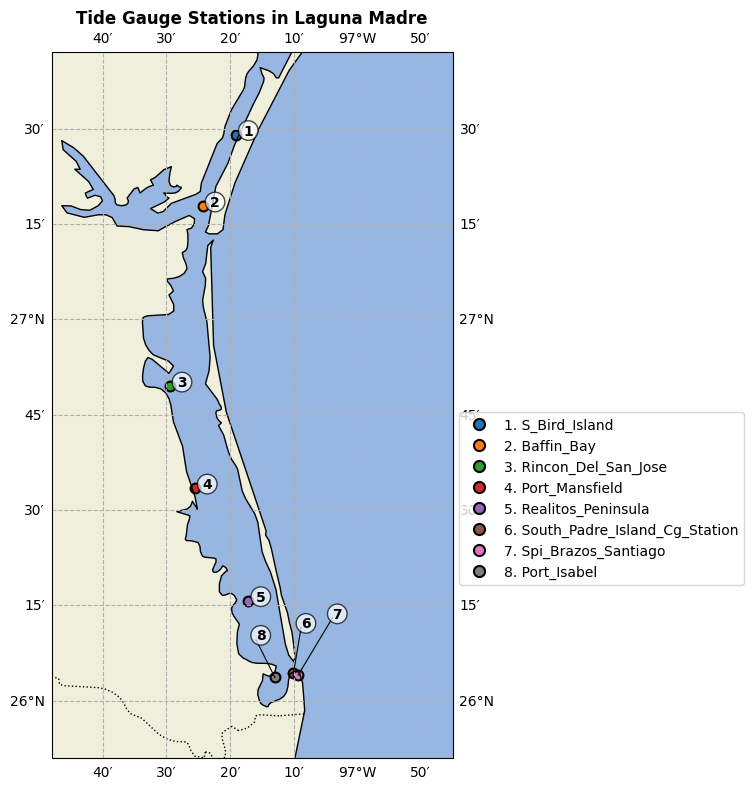

In [11]:
# Plot station locations
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True, linestyle= '--', dms=True, x_inline=False, y_inline=False)
ax.xaxis.set_major_formatter(LONGITUDE_FORMATTER)
ax.yaxis.set_major_formatter(LATITUDE_FORMATTER)

# Add station markers with numbers
station_list = list(valid_stations.items())
for idx, (station_name, _) in enumerate(station_list):
    lat = meta_lm[meta_lm['site_name'] == station_name]['latitude'].values[0]
    lon = meta_lm[meta_lm['site_name'] == station_name]['longitude'].values[0]
    ax.scatter(lon, lat, s=50, marker='o', edgecolors='k', linewidth=1.5)
    
    # For stations 6, 7, 8 (indices 5, 6, 7), offset the label with a line
    if idx >= 5:
        offsets = [(0.02, 0.12), (0.09, 0.15), (-0.05, 0.10)]
        offset_lon = lon + offsets[idx-5][0]
        offset_lat = lat + offsets[idx-5][1]
        ax.plot([lon, offset_lon], [lat, offset_lat], 'k-', linewidth=0.8)
        ax.text(offset_lon, offset_lat, f'{idx+1}', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='circle,pad=0.2', facecolor='white', alpha=0.7))
    else:
        ax.text(lon + 0.02, lat, f'{idx+1}', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='circle,pad=0.2', facecolor='white', alpha=0.7))

# Create legend with station names
legend_labels = [f'{idx+1}. {name}' for idx, (name, _) in enumerate(station_list)]
ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

ax.set_extent([-97.8, -96.75, 25.85, 27.7])
ax.set_title('Tide Gauge Stations in Laguna Madre', fontsize=12, fontweight='bold')

# Create custom legend with colored dots
colors = plt.cm.tab10.colors
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[idx % len(colors)], 
                       markersize=8, markeredgecolor='k', markeredgewidth=1.5) 
           for idx in range(len(station_list))]
ax.legend(handles, legend_labels, loc='best', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.tight_layout()
plt.savefig('figures/report/laguna_madre_stations_map.png', dpi=300, bbox_inches='tight')
plt.show()


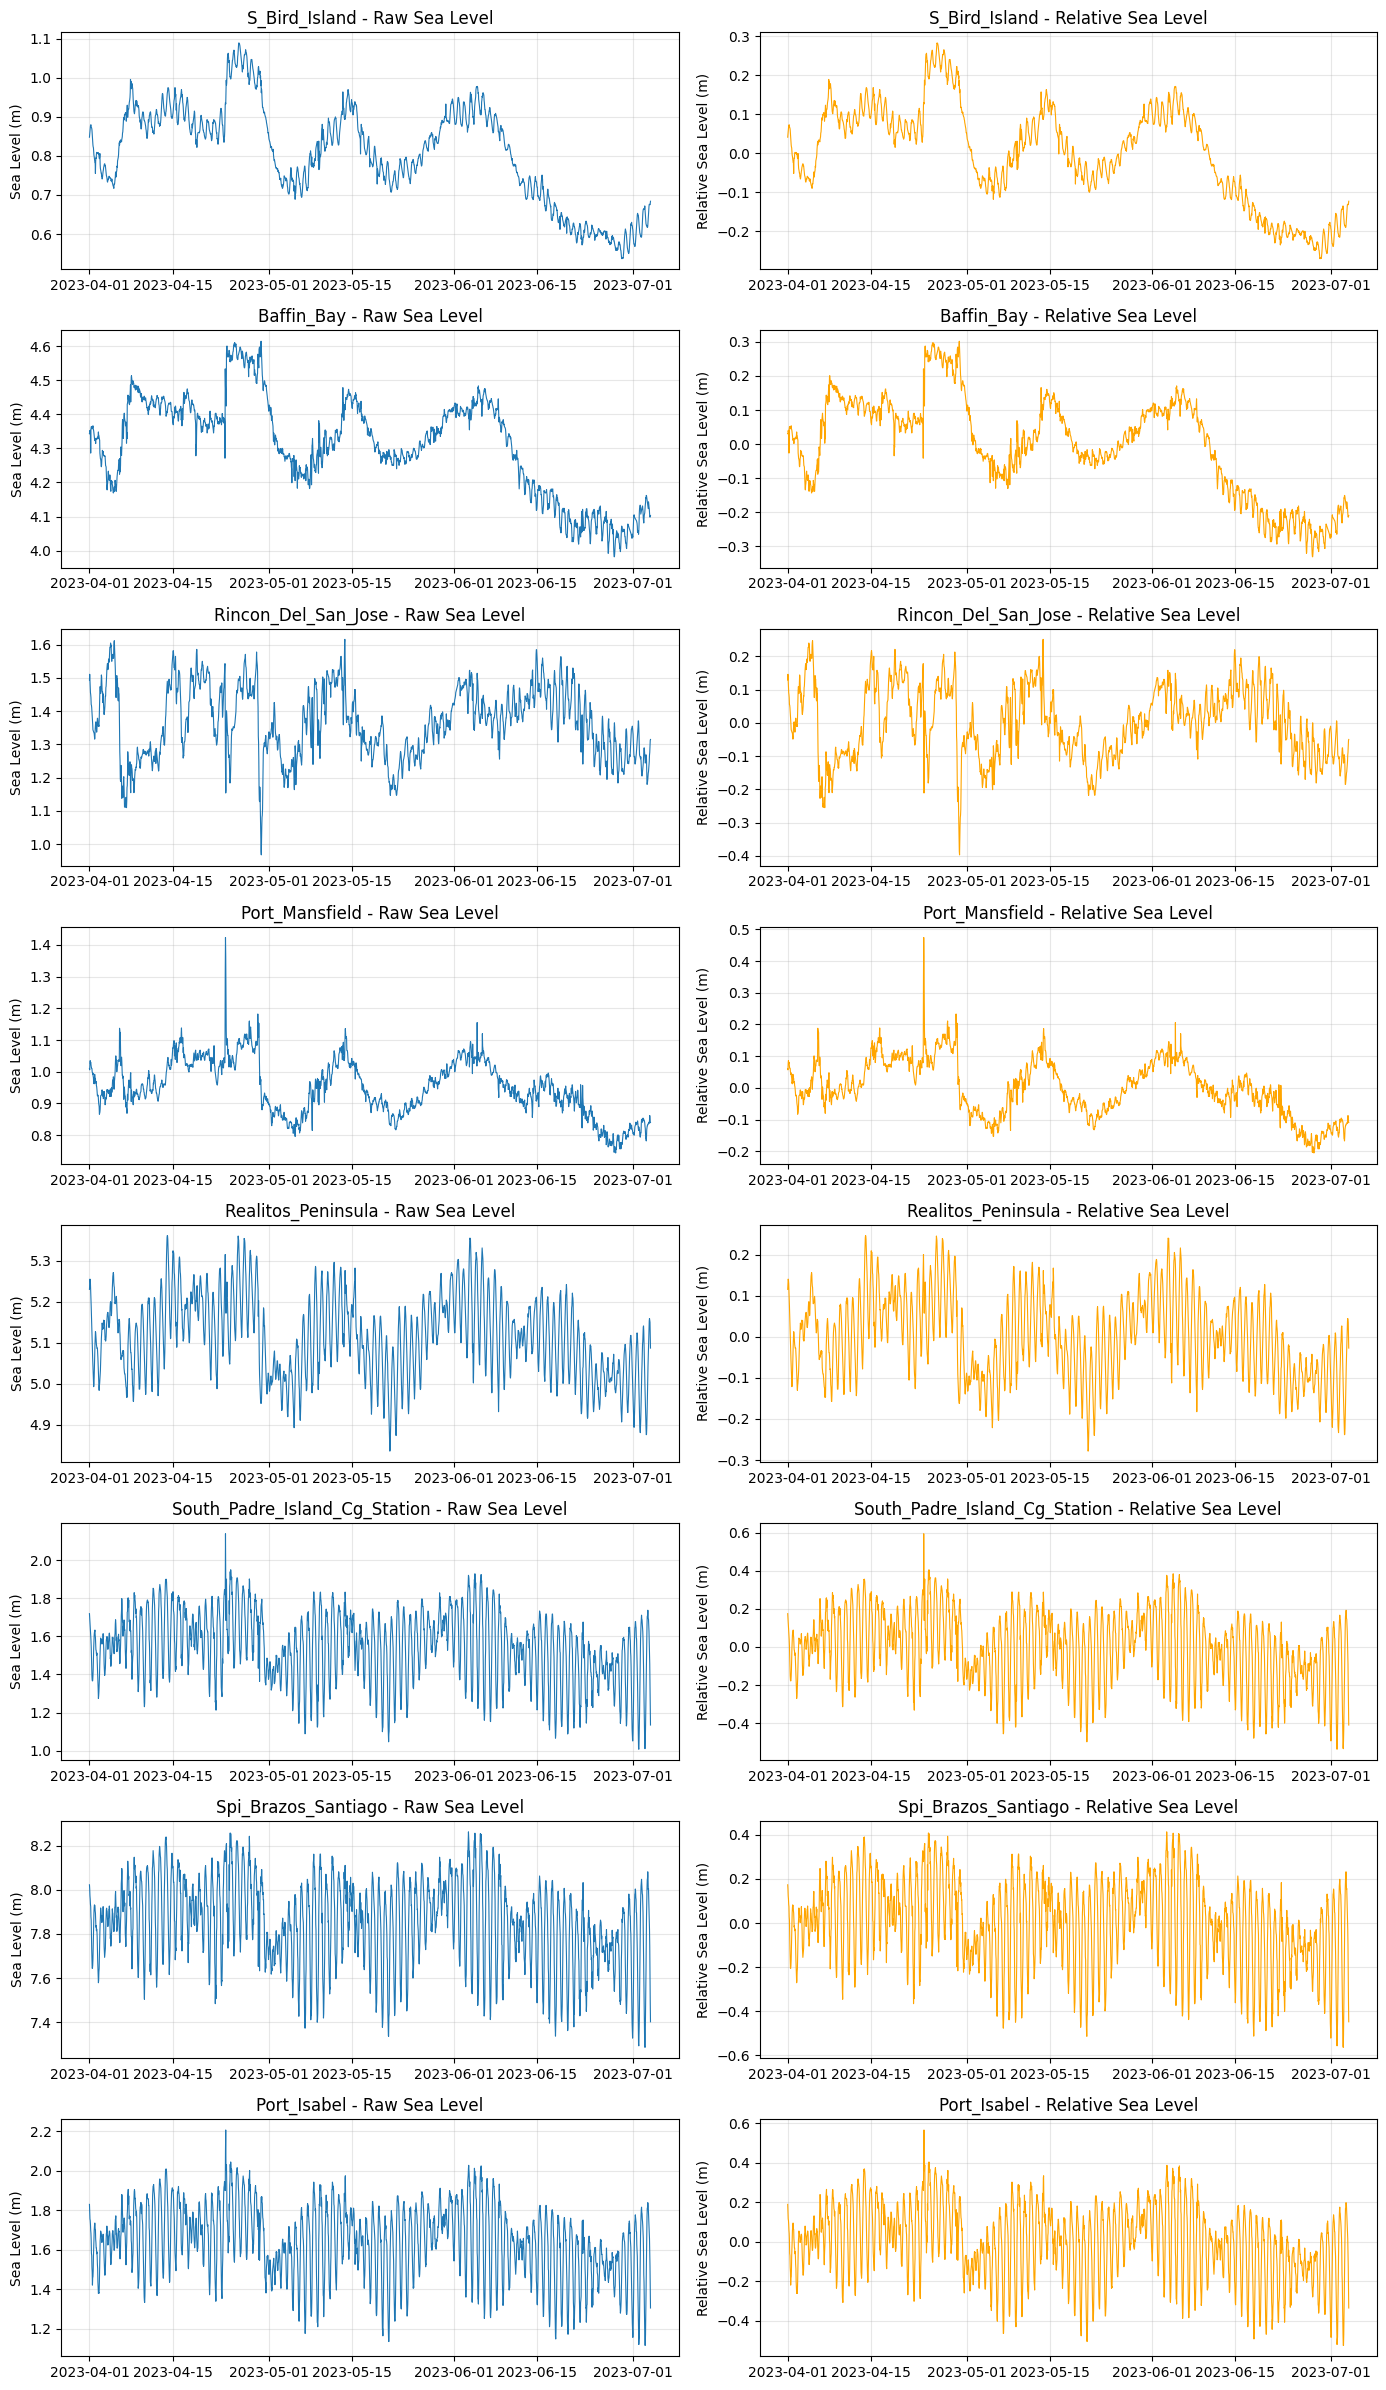

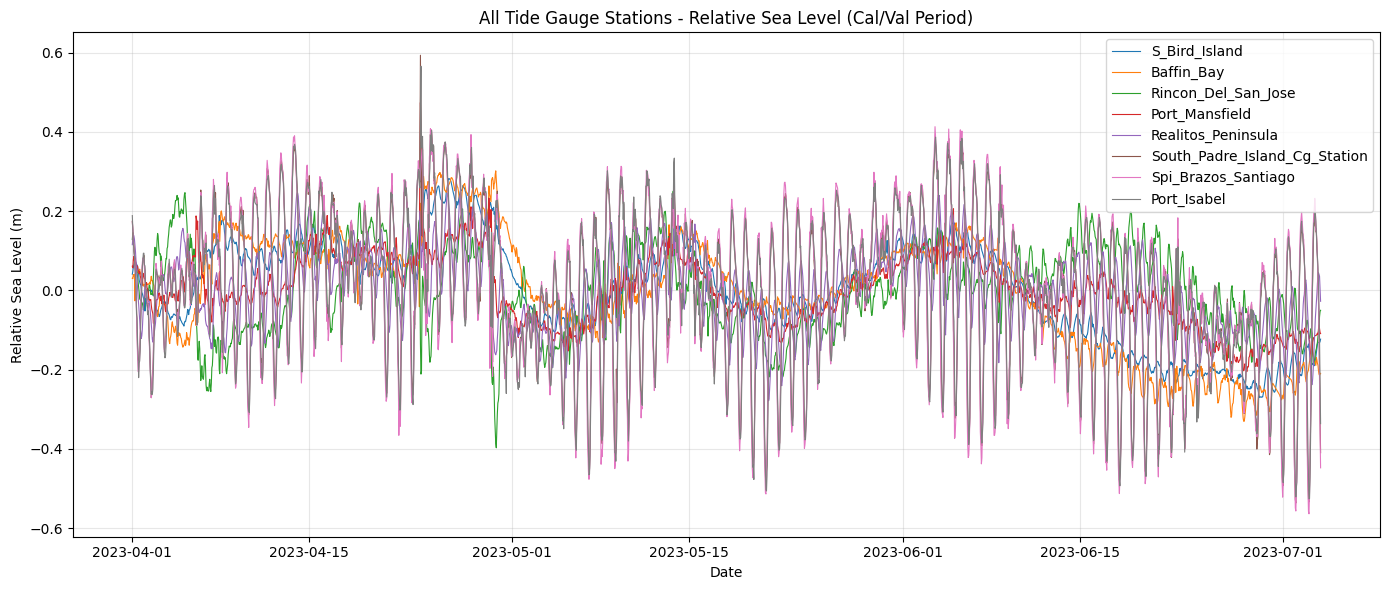

In [ ]:
# Plot individual stations raw&rel sea level and create combined plot
fig, axes = plt.subplots(len(valid_stations), 2, figsize=(14, 3*len(valid_stations)))
if len(valid_stations) == 1:
    axes = axes.reshape(1, -1)

for idx, (station_name, data_cal) in enumerate(valid_stations.items()):
    # Plot raw sea level
    axes[idx, 0].plot(data_cal['datetime'], data_cal['sea_level'], linewidth=0.8)
    axes[idx, 0].set_title(f'{station_name} - Raw Sea Level')
    axes[idx, 0].set_ylabel('Sea Level (m)')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Plot relative sea level (anomaly)
    rel_sea_level = data_cal['sea_level'] - data_cal['sea_level'].mean()
    axes[idx, 1].plot(data_cal['datetime'], rel_sea_level, linewidth=0.8, color='red')
    axes[idx, 1].set_title(f'{station_name} - Relative Sea Level')
    axes[idx, 1].set_ylabel('Relative Sea Level (m)')
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot all stations on one plot
plt.figure(figsize=(14, 6))
for station_name, data_cal in valid_stations.items():
    rel_sea_level = data_cal['sea_level'] - data_cal['sea_level'].mean()
    plt.plot(data_cal['datetime'], rel_sea_level, label=station_name, linewidth=0.8)

plt.xlabel('Date')
plt.ylabel('Relative Sea Level (m)')
plt.title('All Tide Gauge Stations - Relative Sea Level (Cal/Val Period)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

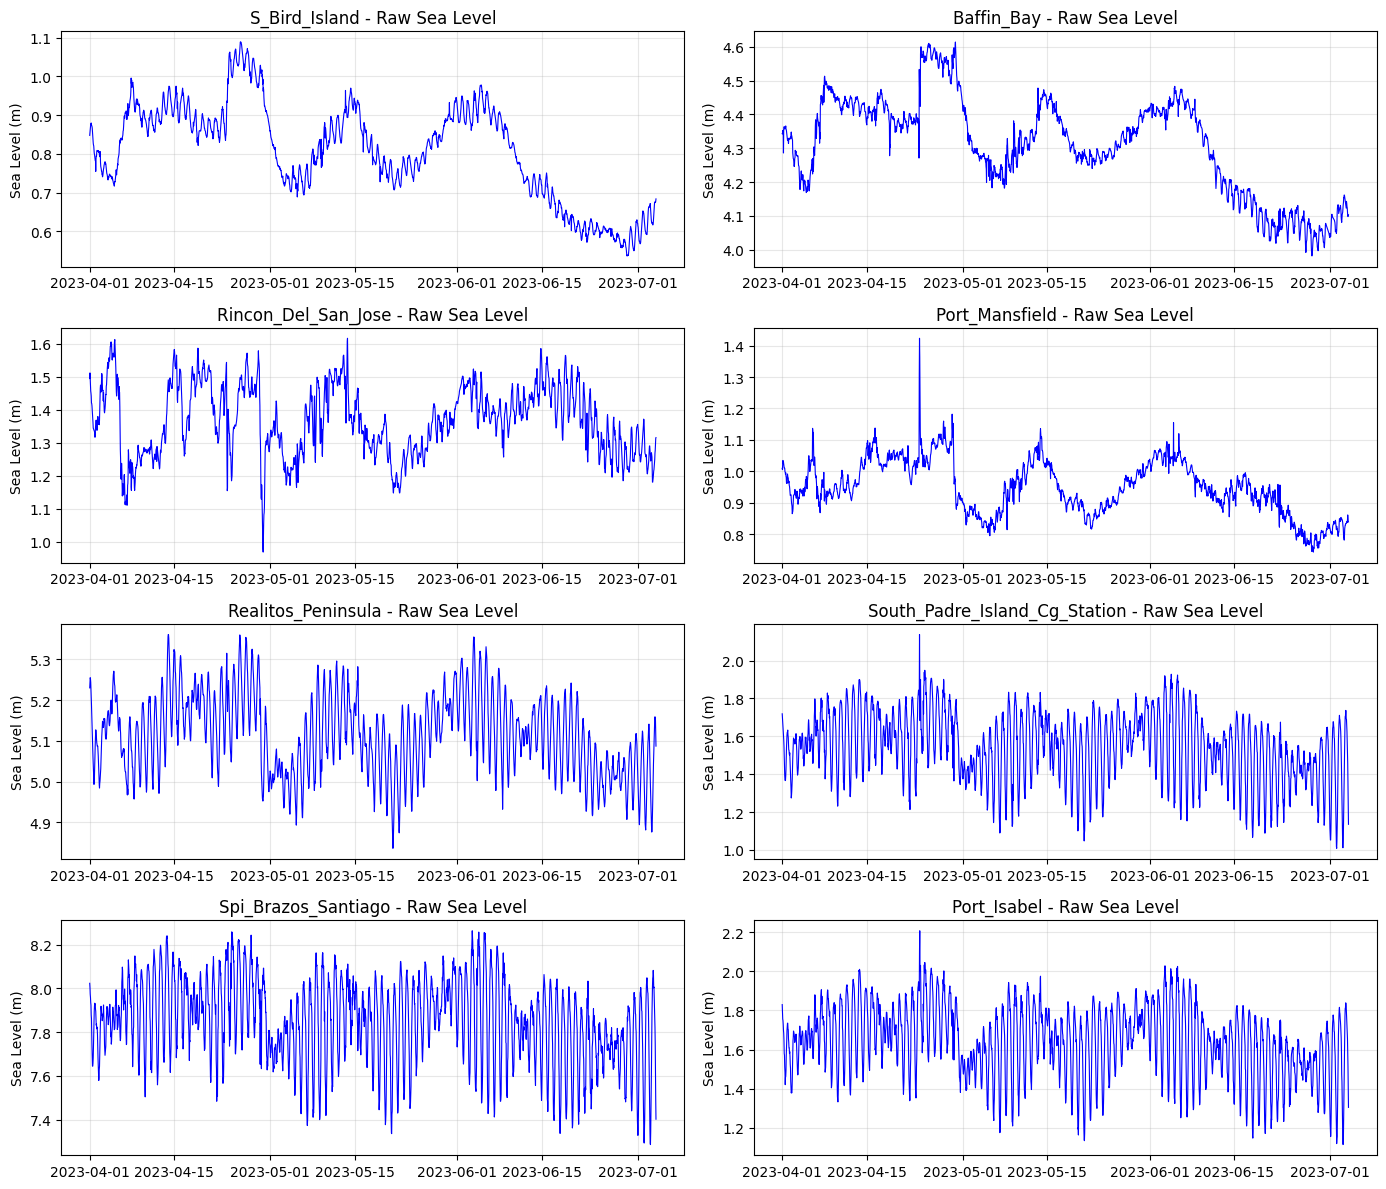

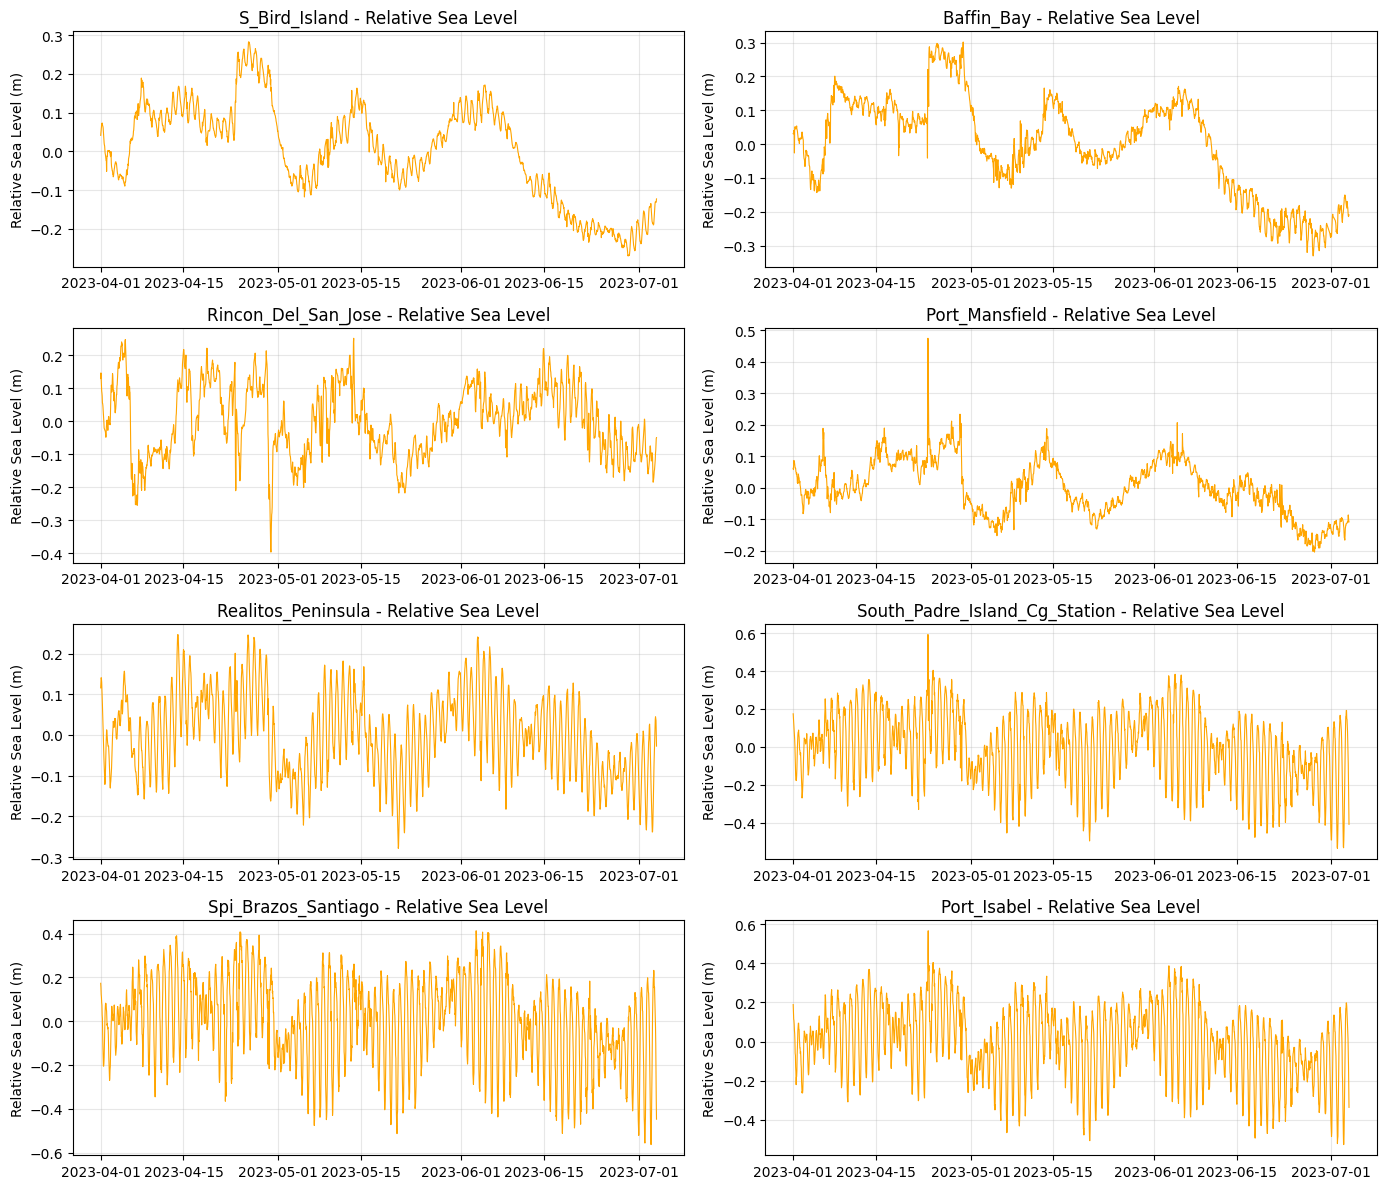

In [ ]:
# Create 4x2 subplots for raw sea level
fig_raw, axes_raw = plt.subplots(4, 2, figsize=(14, 12))
axes_raw = axes_raw.T.flatten()  # iterate down columns first

for idx, (station_name, data_cal) in enumerate(valid_stations.items()):
    axes_raw[idx].plot(data_cal['datetime'], data_cal['sea_level'], linewidth=0.8, color='blue')
    axes_raw[idx].set_title(f'{station_name} - Raw Sea Level')
    axes_raw[idx].set_ylabel('Sea Level (m)')
    axes_raw[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/8stations_LM_raw_subplots.png', dpi=300, bbox_inches='tight')
plt.show()

# Create 4x2 subplots for relative sea level
fig_rel, axes_rel = plt.subplots(4, 2, figsize=(14, 12))
axes_rel = axes_rel.T.flatten()  # iterate down columns first

for idx, (station_name, data_cal) in enumerate(valid_stations.items()):
    rel_sea_level = data_cal['sea_level'] - data_cal['sea_level'].mean()
    axes_rel[idx].plot(data_cal['datetime'], rel_sea_level, linewidth=0.8, color='red')
    axes_rel[idx].set_title(f'{station_name} - Relative Sea Level')
    axes_rel[idx].set_ylabel('Relative Sea Level (m)')
    axes_rel[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/8stations_LM_relative_subplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Plot 4 in lagoon and 4 near mouth of lagoon separately 

# Plot first 4 stations (within Lagoon)
fig, ax = plt.subplots(figsize=(14, 5))
station_list = list(valid_stations.items())
colors_custom = ['orange', 'purple', 'darkgreen', 'blue']
for idx, (station_name, data_df) in enumerate(station_list[:4]):
    rel_sea_level = data_df['sea_level'] - data_df['sea_level'].mean()
    ax.plot(data_df['datetime'], rel_sea_level, label=station_name, linewidth=0.8, color=colors_custom[idx])

ax.set_title('Relative Sea Level - Within Lagoon', fontsize=12, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Relative Sea Level (m)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('figures/4stations_LM_within_lagoon.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot last 4 stations (near mouth of Lagoon)
fig, ax = plt.subplots(figsize=(14, 5))
#colors_custom2 = ['darkblue', 'red', 'black', 'pink']
for idx, (station_name, data_df) in enumerate(station_list[4:]):
    rel_sea_level = data_df['sea_level'] - data_df['sea_level'].mean()
    ax.plot(data_df['datetime'], rel_sea_level, label=station_name, linewidth=0.8, color=colors_custom[idx])

ax.set_title('Relative Sea Level - Near Mouth of Lagoon', fontsize=12, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Relative Sea Level (m)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('figures/4stations_LM_near_mouth.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Save processed data to netCDF files for each station
import os

# Create the output directory if it doesn't exist
output_dir = '/home/nsv9/data/GESLA_LM/'
os.makedirs(output_dir, exist_ok=True)

# Process each valid station
for station_name, data_df in valid_stations.items():
    # Get latitude and longitude from meta_lm
    lat = meta_lm[meta_lm['site_name'] == station_name]['latitude'].values[0]
    lon = meta_lm[meta_lm['site_name'] == station_name]['longitude'].values[0]
    
    # Compute relative sea level
    rel_sea_level = data_df['sea_level'] - data_df['sea_level'].mean()
    
    # Add lat and lon as columns (constant for all rows)
    data_df = data_df.copy()
    data_df['latitude'] = lat
    data_df['longitude'] = lon
    data_df['rel_sea_level'] = rel_sea_level
    
    # Create xarray Dataset
    ds = xr.Dataset({
        'sea_level': (['time'], data_df['sea_level']),
        'rel_sea_level': (['time'], data_df['rel_sea_level']),
        'qc_flag': (['time'], data_df['qc_flag']),
        'use_flag': (['time'], data_df['use_flag']),
        'latitude': lat,
        'longitude': lon
    }, coords={
        'time': data_df['datetime']
    })
    
    # Save to netCDF
    filename = f"{station_name}_calval_LM.nc"
    filepath = os.path.join(output_dir, filename)
    ds.to_netcdf(filepath)
    print(f"Saved {filepath}")

Saved /home/nsv9/data/GESLA_LM/Port_Isabel_calval_LM.nc
Saved /home/nsv9/data/GESLA_LM/Port_Mansfield_calval_LM.nc
Saved /home/nsv9/data/GESLA_LM/Baffin_Bay_calval_LM.nc
Saved /home/nsv9/data/GESLA_LM/Rincon_Del_San_Jose_calval_LM.nc
Saved /home/nsv9/data/GESLA_LM/S_Bird_Island_calval_LM.nc
Saved /home/nsv9/data/GESLA_LM/South_Padre_Island_Cg_Station_calval_LM.nc
Saved /home/nsv9/data/GESLA_LM/Spi_Brazos_Santiago_calval_LM.nc
Saved /home/nsv9/data/GESLA_LM/Realitos_Peninsula_calval_LM.nc


## Match to SWOT timestamps, take 1 daily TG value

In [35]:
swot_e2_gom = xr.open_dataset('data/SWOT_datacube/swot_expert_l2_calval_gom.nc')
swot_e3_gom = xr.open_dataset('data/SWOT_datacube/swot_expert_l3_calval_gom.nc')

e2_df = swot_e2_gom.to_dataframe()

e3_df = swot_e3_gom.to_dataframe()


In [53]:
e2 = swot_e2_gom.copy()
e2['timec']

<xarray.DataArray 'timec' (timec: 92)> Size: 736B
array(['2023-04-01T17:26:58.949176039', '2023-04-02T17:17:36.730266133',
       '2023-04-03T17:08:14.479179814', '2023-04-04T16:58:52.195681868',
       '2023-04-05T16:49:29.877421819',                           'NaT',
       '2023-04-07T16:30:46.260756694', '2023-04-08T16:21:24.437114983',
       '2023-04-09T16:12:02.576610660', '2023-04-10T16:02:40.682679283',
       '2023-04-11T15:53:18.755975905', '2023-04-12T15:43:56.799531560',
       '2023-04-13T15:34:34.814623357', '2023-04-14T15:25:12.803690456',
       '2023-04-15T15:15:50.760220570', '2023-04-16T15:06:28.683114978',
       '2023-04-17T14:57:06.571816336', '2023-04-18T14:47:44.423934080',
       '2023-04-19T14:38:22.236476336', '2023-04-20T14:29:00.007042310',
       '2023-04-21T14:19:37.743333816', '2023-04-22T14:10:15.682818868',
       '2023-04-23T14:00:53.672252414', '2023-04-24T13:51:31.623717652',
       '2023-04-25T13:42:09.535100242', '2023-04-26T13:32:47.423681136',
       '2023-04-27T13:23:25.289777718', '2023-04-28T13:14:03.129385120',
       '2023-04-29T13:04:40.942240780', '2023-04-30T12:55:32.805560470',
       '2023-05-01T12:45:56.481033136', '2023-05-02T12:36:34.200850572',
       '2023-05-03T12:27:11.887479264', '2023-05-04T12:17:49.544222534',
       '2023-05-05T12:08:27.168617062', '2023-05-06T11:59:04.964293580',
       '2023-05-07T11:49:42.818459794', '2023-05-08T11:40:20.648125808',
       '2023-05-09T11:30:58.450405046', '2023-05-10T11:21:36.223880352',
       '2023-05-11T11:12:13.966136984', '2023-05-12T11:02:51.675771914',
       '2023-05-13T10:53:29.356568054', '2023-05-14T10:44:06.941004792',
       '2023-05-15T10:34:44.548900184', '2023-05-16T10:25:22.126539078',
       '2023-05-17T10:15:59.673754102', '2023-05-18T10:06:37.505981506',
       '2023-05-19T09:57:15.575365780', '2023-05-23T09:19:47.594087918',
       '2023-05-24T09:10:25.530796172', '2023-05-25T09:01:03.441013324',
       '2023-05-26T08:51:41.320191574', '2023-05-27T08:42:19.170510438',
       '2023-05-28T08:32:56.993119640', '2023-05-29T08:23:34.785424198',
       '2023-05-30T08:14:12.548228882', '2023-05-31T08:04:50.282381164',
       '2023-06-01T07:55:27.990391156', '2023-06-02T07:46:05.738180986',
       '2023-06-03T07:36:43.711194922', '2023-06-04T07:27:21.662088852',
       '2023-06-05T07:17:59.589968376', '2023-06-06T07:08:37.490251162',
       '2023-06-07T06:59:15.358965272', '2023-06-08T06:49:53.194951796',
       '2023-06-09T06:40:30.996137940', '2023-06-10T06:31:08.766025420',
       '2023-06-11T06:21:46.503628262', '2023-06-12T06:12:24.215612032',
       '2023-06-13T06:03:01.899715086', '2023-06-14T05:53:39.558616084',
       '2023-06-15T05:44:17.196959262', '2023-06-16T05:34:54.814854104',
       '2023-06-17T05:25:32.651478244', '2023-06-18T05:16:10.812337528',
       '2023-06-19T05:06:48.942184488', '2023-06-20T04:57:27.037271574',
       '2023-06-21T04:48:05.095381562', '2023-06-22T04:38:43.119668628',
       '2023-06-23T04:29:21.108871974', '2023-06-24T04:19:59.062935246',
       '2023-06-25T04:10:36.985939798', '2023-06-26T04:01:14.876111872',
       '2023-06-27T03:51:52.738831426', '2023-06-28T03:42:30.571155644',
       '2023-06-29T03:33:08.379214274', '2023-06-30T03:23:46.160346868',
       '2023-07-01T03:14:24.037220872', '2023-07-02T03:05:02.106570506',
       '2023-07-03T02:55:40.145830492', '2023-07-04T02:46:18.150985132'],
      dtype='datetime64[ns]')
Coordinates:
  * timec    (timec) datetime64[ns] 736B 2023-04-01T17:26:58.949176039 ... 20...

In [51]:
match_times = e2['timec'].dt.round('1h')
match_times

<xarray.DataArray 'round' (timec: 92)> Size: 736B
array(['2023-04-01T17:00:00.000000000', '2023-04-02T17:00:00.000000000',
       '2023-04-03T17:00:00.000000000', '2023-04-04T17:00:00.000000000',
       '2023-04-05T17:00:00.000000000',                           'NaT',
       '2023-04-07T17:00:00.000000000', '2023-04-08T16:00:00.000000000',
       '2023-04-09T16:00:00.000000000', '2023-04-10T16:00:00.000000000',
       '2023-04-11T16:00:00.000000000', '2023-04-12T16:00:00.000000000',
       '2023-04-13T16:00:00.000000000', '2023-04-14T15:00:00.000000000',
       '2023-04-15T15:00:00.000000000', '2023-04-16T15:00:00.000000000',
       '2023-04-17T15:00:00.000000000', '2023-04-18T15:00:00.000000000',
       '2023-04-19T15:00:00.000000000', '2023-04-20T14:00:00.000000000',
       '2023-04-21T14:00:00.000000000', '2023-04-22T14:00:00.000000000',
       '2023-04-23T14:00:00.000000000', '2023-04-24T14:00:00.000000000',
       '2023-04-25T14:00:00.000000000', '2023-04-26T14:00:00.000000000',
       '2023-04-27T13:00:00.000000000', '2023-04-28T13:00:00.000000000',
       '2023-04-29T13:00:00.000000000', '2023-04-30T13:00:00.000000000',
       '2023-05-01T13:00:00.000000000', '2023-05-02T13:00:00.000000000',
       '2023-05-03T12:00:00.000000000', '2023-05-04T12:00:00.000000000',
       '2023-05-05T12:00:00.000000000', '2023-05-06T12:00:00.000000000',
       '2023-05-07T12:00:00.000000000', '2023-05-08T12:00:00.000000000',
       '2023-05-09T12:00:00.000000000', '2023-05-10T11:00:00.000000000',
...
       '2023-05-28T09:00:00.000000000', '2023-05-29T08:00:00.000000000',
       '2023-05-30T08:00:00.000000000', '2023-05-31T08:00:00.000000000',
       '2023-06-01T08:00:00.000000000', '2023-06-02T08:00:00.000000000',
       '2023-06-03T08:00:00.000000000', '2023-06-04T07:00:00.000000000',
       '2023-06-05T07:00:00.000000000', '2023-06-06T07:00:00.000000000',
       '2023-06-07T07:00:00.000000000', '2023-06-08T07:00:00.000000000',
       '2023-06-09T07:00:00.000000000', '2023-06-10T07:00:00.000000000',
       '2023-06-11T06:00:00.000000000', '2023-06-12T06:00:00.000000000',
       '2023-06-13T06:00:00.000000000', '2023-06-14T06:00:00.000000000',
       '2023-06-15T06:00:00.000000000', '2023-06-16T06:00:00.000000000',
       '2023-06-17T05:00:00.000000000', '2023-06-18T05:00:00.000000000',
       '2023-06-19T05:00:00.000000000', '2023-06-20T05:00:00.000000000',
       '2023-06-21T05:00:00.000000000', '2023-06-22T05:00:00.000000000',
       '2023-06-23T04:00:00.000000000', '2023-06-24T04:00:00.000000000',
       '2023-06-25T04:00:00.000000000', '2023-06-26T04:00:00.000000000',
       '2023-06-27T04:00:00.000000000', '2023-06-28T04:00:00.000000000',
       '2023-06-29T04:00:00.000000000', '2023-06-30T03:00:00.000000000',
       '2023-07-01T03:00:00.000000000', '2023-07-02T03:00:00.000000000',
       '2023-07-03T03:00:00.000000000', '2023-07-04T03:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * timec    (timec) datetime64[ns] 736B 2023-04-01T17:26:58.949176039 ... 20...

In [57]:
# Save processed hour-matched data to netCDF files for each station
import os

# Create the output directory if it doesn't exist
output_dir = '/home/nsv9/data/GESLA_LM_matchhr/'
os.makedirs(output_dir, exist_ok=True)

# Process each valid station
for station_name, data_df in valid_stations.items():
    # Get latitude and longitude from meta_lm
    lat = meta_lm[meta_lm['site_name'] == station_name]['latitude'].values[0]
    lon = meta_lm[meta_lm['site_name'] == station_name]['longitude'].values[0]
    
    # Compute relative sea level
    rel_sea_level = data_df['sea_level'] - data_df['sea_level'].mean()
    
    # Add lat and lon as columns (constant for all rows)
    data_df = data_df.copy()
    data_df['latitude'] = lat
    data_df['longitude'] = lon
    data_df['rel_sea_level'] = rel_sea_level
    
    # Create the initial xarray Dataset
    ds = xr.Dataset({
        'sea_level': (['time'], data_df['sea_level']),
        'rel_sea_level': (['time'], data_df['rel_sea_level']),
        'qc_flag': (['time'], data_df['qc_flag']),
        'use_flag': (['time'], data_df['use_flag']),
        'latitude': lat,
        'longitude': lon
    }, coords={
        'time': data_df['datetime']
    })
    
    # --- NEW FILTERING LOGIC ---
    
    # 1. Round the station times to the nearest hour
    #ds.coords['time'] = ds['time'].dt.round('1H')
    
    # 2. Drop duplicates (in case the station had sub-hourly data 
    # that now all round to the same hour)
    ds = ds.drop_duplicates('time')
    
    # 3. Only keep time steps that exist in your 'match_times' list
    # .isin() creates a mask, and drop=True removes the 'False' entries
    ds = ds.where(ds.time.isin(match_times), drop=True)
    
    # ---------------------------

    # Save to netCDF (only if the dataset isn't empty after filtering)
    if len(ds.time) > 0:
        filename = f"{station_name}_matchhr.nc"
        filepath = os.path.join(output_dir, filename)
        ds.to_netcdf(filepath)
        print(f"Saved {filepath} with {len(ds.time)} matching hours.")
    else:
        print(f"Skipping {station_name}: No matching timestamps found.")

Saved /home/nsv9/data/GESLA_LM_matchhr/S_Bird_Island_matchhr.nc with 90 matching hours.
Saved /home/nsv9/data/GESLA_LM_matchhr/Baffin_Bay_matchhr.nc with 89 matching hours.
Saved /home/nsv9/data/GESLA_LM_matchhr/Rincon_Del_San_Jose_matchhr.nc with 89 matching hours.
Saved /home/nsv9/data/GESLA_LM_matchhr/Port_Mansfield_matchhr.nc with 90 matching hours.
Saved /home/nsv9/data/GESLA_LM_matchhr/Realitos_Peninsula_matchhr.nc with 90 matching hours.
Saved /home/nsv9/data/GESLA_LM_matchhr/South_Padre_Island_Cg_Station_matchhr.nc with 90 matching hours.
Saved /home/nsv9/data/GESLA_LM_matchhr/Spi_Brazos_Santiago_matchhr.nc with 90 matching hours.
Saved /home/nsv9/data/GESLA_LM_matchhr/Port_Isabel_matchhr.nc with 90 matching hours.


In [56]:
ds['time']

<xarray.DataArray 'time' (time: 90)> Size: 720B
array(['2023-04-01T17:00:00.000000', '2023-04-02T17:00:00.000000',
       '2023-04-03T17:00:00.000000', '2023-04-04T17:00:00.000000',
       '2023-04-05T17:00:00.000000', '2023-04-07T17:00:00.000000',
       '2023-04-08T16:00:00.000000', '2023-04-09T16:00:00.000000',
       '2023-04-10T16:00:00.000000', '2023-04-11T16:00:00.000000',
       '2023-04-12T16:00:00.000000', '2023-04-13T16:00:00.000000',
       '2023-04-14T15:00:00.000000', '2023-04-15T15:00:00.000000',
       '2023-04-16T15:00:00.000000', '2023-04-17T15:00:00.000000',
       '2023-04-18T15:00:00.000000', '2023-04-19T15:00:00.000000',
       '2023-04-20T14:00:00.000000', '2023-04-21T14:00:00.000000',
       '2023-04-22T14:00:00.000000', '2023-04-23T14:00:00.000000',
       '2023-04-24T14:00:00.000000', '2023-04-25T14:00:00.000000',
       '2023-04-26T14:00:00.000000', '2023-04-27T13:00:00.000000',
       '2023-04-28T13:00:00.000000', '2023-04-29T13:00:00.000000',
       '2023-04-30T13:00:00.000000', '2023-05-01T13:00:00.000000',
       '2023-05-02T13:00:00.000000', '2023-05-03T12:00:00.000000',
       '2023-05-04T12:00:00.000000', '2023-05-05T12:00:00.000000',
       '2023-05-06T12:00:00.000000', '2023-05-07T12:00:00.000000',
       '2023-05-08T12:00:00.000000', '2023-05-09T12:00:00.000000',
       '2023-05-10T11:00:00.000000', '2023-05-11T11:00:00.000000',
       '2023-05-12T11:00:00.000000', '2023-05-13T11:00:00.000000',
       '2023-05-14T11:00:00.000000', '2023-05-15T11:00:00.000000',
       '2023-05-16T10:00:00.000000', '2023-05-17T10:00:00.000000',
       '2023-05-18T10:00:00.000000', '2023-05-19T10:00:00.000000',
       '2023-05-23T09:00:00.000000', '2023-05-24T09:00:00.000000',
       '2023-05-25T09:00:00.000000', '2023-05-26T09:00:00.000000',
       '2023-05-27T09:00:00.000000', '2023-05-28T09:00:00.000000',
       '2023-05-29T08:00:00.000000', '2023-05-30T08:00:00.000000',
       '2023-05-31T08:00:00.000000', '2023-06-01T08:00:00.000000',
       '2023-06-02T08:00:00.000000', '2023-06-03T08:00:00.000000',
       '2023-06-04T07:00:00.000000', '2023-06-05T07:00:00.000000',
       '2023-06-06T07:00:00.000000', '2023-06-07T07:00:00.000000',
       '2023-06-08T07:00:00.000000', '2023-06-09T07:00:00.000000',
       '2023-06-10T07:00:00.000000', '2023-06-11T06:00:00.000000',
       '2023-06-12T06:00:00.000000', '2023-06-13T06:00:00.000000',
       '2023-06-14T06:00:00.000000', '2023-06-15T06:00:00.000000',
       '2023-06-16T06:00:00.000000', '2023-06-17T05:00:00.000000',
       '2023-06-18T05:00:00.000000', '2023-06-19T05:00:00.000000',
       '2023-06-20T05:00:00.000000', '2023-06-21T05:00:00.000000',
       '2023-06-22T05:00:00.000000', '2023-06-23T04:00:00.000000',
       '2023-06-24T04:00:00.000000', '2023-06-25T04:00:00.000000',
       '2023-06-26T04:00:00.000000', '2023-06-27T04:00:00.000000',
       '2023-06-28T04:00:00.000000', '2023-06-29T04:00:00.000000',
       '2023-06-30T03:00:00.000000', '2023-07-01T03:00:00.000000',
       '2023-07-02T03:00:00.000000', '2023-07-03T03:00:00.000000'],
      dtype='datetime64[us]')
Coordinates:
  * time     (time) datetime64[us] 720B 2023-04-01T17:00:00 ... 2023-07-03T03...

In [ ]:
# Save processed data to netCDF files for each station
import os

# Create the output directory if it doesn't exist
output_dir = '/home/nsv9/data/GESLA_LM/'
os.makedirs(output_dir, exist_ok=True)

# Process each valid station
for station_name, data_df in valid_stations.items():
    # Get latitude and longitude from meta_lm
    lat = meta_lm[meta_lm['site_name'] == station_name]['latitude'].values[0]
    lon = meta_lm[meta_lm['site_name'] == station_name]['longitude'].values[0]
    
    # Compute relative sea level
    rel_sea_level = data_df['sea_level'] - data_df['sea_level'].mean()
    
    # Add lat and lon as columns (constant for all rows)
    data_df = data_df.copy()
    data_df['latitude'] = lat
    data_df['longitude'] = lon
    data_df['rel_sea_level'] = rel_sea_level
    
    # Create xarray Dataset
    ds = xr.Dataset({
        'sea_level': (['time'], data_df['sea_level']),
        'rel_sea_level': (['time'], data_df['rel_sea_level']),
        'qc_flag': (['time'], data_df['qc_flag']),
        'use_flag': (['time'], data_df['use_flag']),
        'latitude': lat,
        'longitude': lon
    }, coords={
        'time': data_df['datetime']
    })
    
    # Save to netCDF
    filename = f"{station_name}_calval_LM.nc"
    filepath = os.path.join(output_dir, filename)
    ds.to_netcdf(filepath)
    print(f"Saved {filepath}")

In [ ]:
# plots

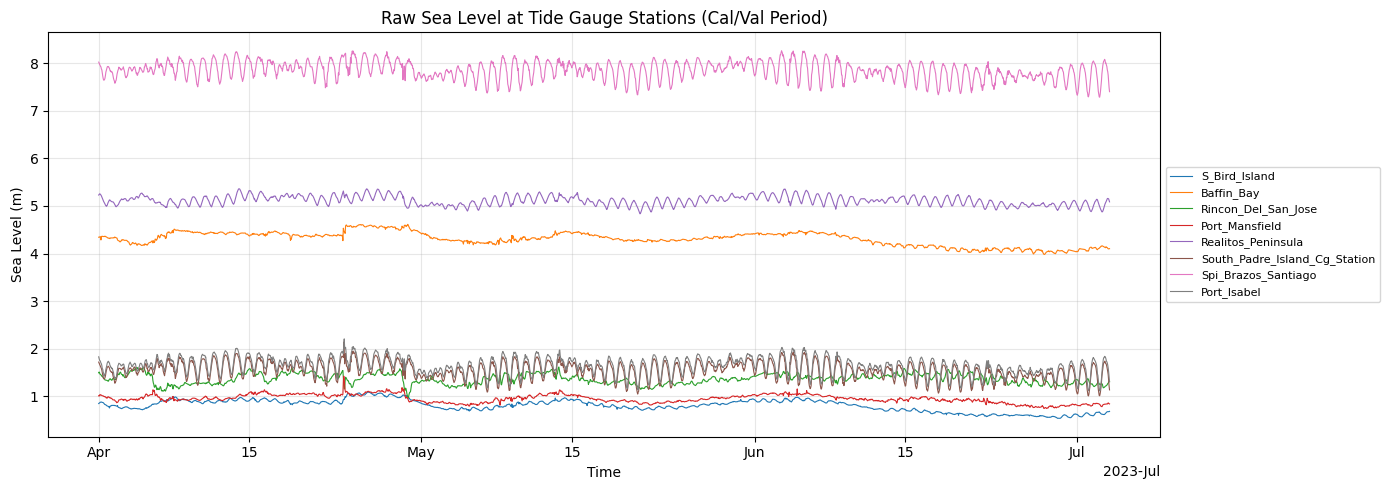

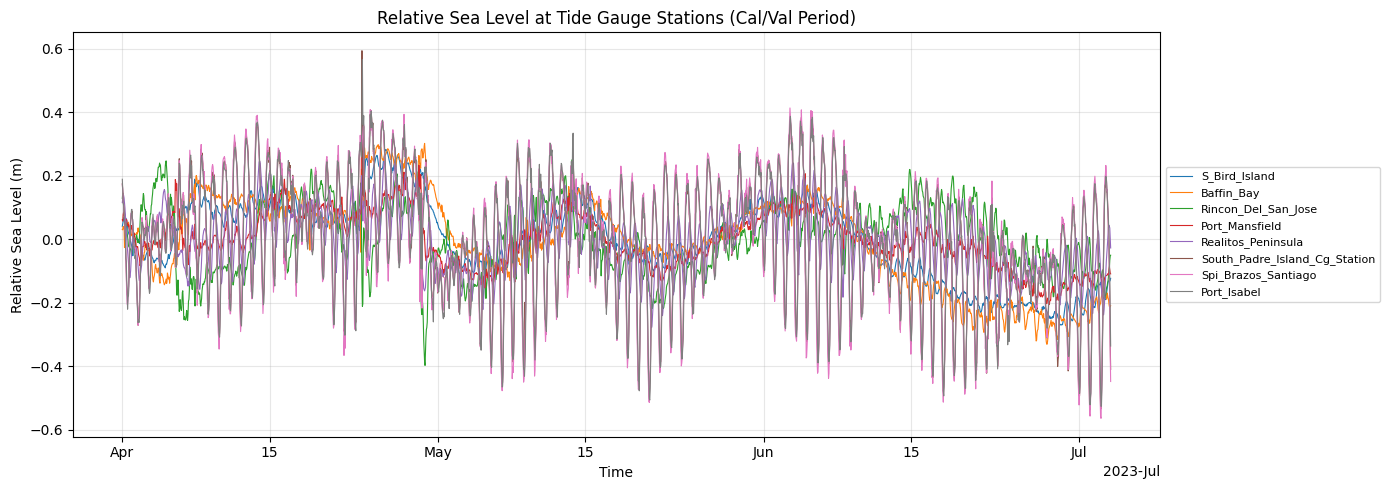

In [ ]:
# Check - load and plot all netCDF files

files = glob(os.path.join(output_dir, '*_calval_LM.nc'))
stations_data = {}
for file in files:
    ds = xr.open_dataset(file)
    station_name = file.split('/')[-1].replace('_calval_LM.nc', '')
    stations_data[station_name] = ds

# reorder stations_data to match the order of valid_stations
ordered_stations_data = {}
for station_name in valid_stations.keys():
    if station_name in stations_data:
        ordered_stations_data[station_name] = stations_data[station_name]
stations_data = ordered_stations_data

# Plot raw sea level
fig1, ax1 = plt.subplots(figsize=(14, 5))
for station_name, ds in stations_data.items():
    ds['sea_level'].plot(ax=ax1, label=station_name, linewidth=0.8)

ax1.set_title('Raw Sea Level at Tide Gauge Stations (Cal/Val Period)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Sea Level (m)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.savefig('figures/8stations_LM_SL_raw_CalVal2023.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot relative sea level
fig2, ax2 = plt.subplots(figsize=(14, 5))
for station_name, ds in stations_data.items():
    ds['rel_sea_level'].plot(ax=ax2, label=station_name, linewidth=0.8)

ax2.set_title('Relative Sea Level at Tide Gauge Stations (Cal/Val Period)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Relative Sea Level (m)')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.savefig('figures/8stations_LM_SL_relative_CalVal2023.png', dpi=300, bbox_inches='tight')
plt.show()


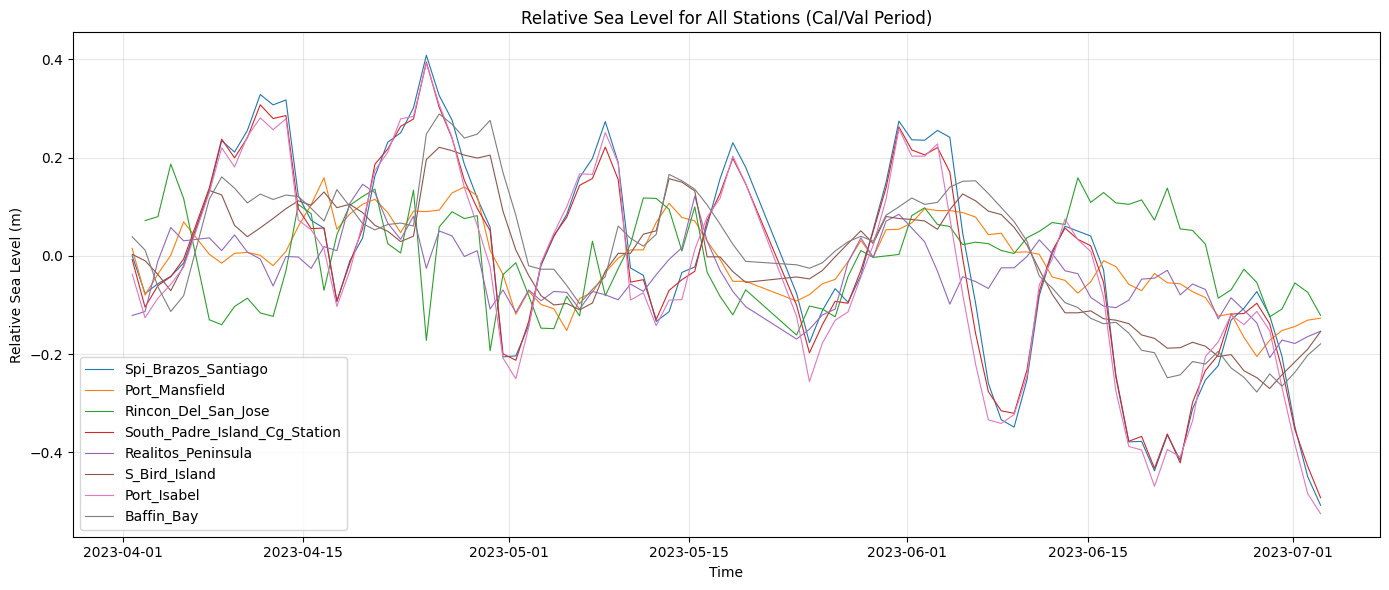

In [58]:
import matplotlib.animation as animation

# Load all netCDF files
files = glob(os.path.join(output_dir, '*_matchhr.nc'))
stations_data = {}
for file in files:
    ds = xr.open_dataset(file)
    station_name = file.split('/')[-1].replace('_matchhr.nc', '')
    stations_data[station_name] = ds

# Plot relative sea level for all stations
plt.figure(figsize=(14, 6))
for name, ds in stations_data.items():
    plt.plot(ds['time'], ds['rel_sea_level'], label=name, linewidth=0.8)
plt.xlabel('Time')
plt.ylabel('Relative Sea Level (m)')
plt.title('Relative Sea Level for All Stations (Cal/Val Period)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Import libraries
import xarray as xr
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from glob import glob
#import swot_ssh_utils as swot
import os
import earthaccess
from dask.distributed import Client
import dask
import pandas as pd

from cartopy import crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import pyplot as plt


import os
import re
from datetime import datetime

## ALL interpolations

organize later, but screw it we goin all in

In [ ]:
swot_e2_gom = xr.open_dataset('data/SWOT_datacube/swot_expert_l2_calval_gom.nc')
swot_e3_gom = xr.open_dataset('data/SWOT_datacube/swot_expert_l3_calval_gom.nc')


In [ ]:
e2_df = swot_e2_gom.to_dataframe()

e3_df = swot_e3_gom.to_dataframe()


In [7]:
swot_df = e2_df

if 'ssha_karin_2' in swot_df.columns:
    swot_var = 'ssha_karin_2'
else: swot_var = 'ssha_unfiltered'

swot_df_dropna = swot_df.dropna(axis=0, how='any', subset=[swot_var,'latitude', 'longitude', 'time'], 
                                inplace=False)
swot_df_dropna

time  \
timec                         num_lines num_pixels num_sides                                 
2023-04-01 17:26:58.949176039 0         1          0         2023-04-01 17:26:15.371241984   
                                                   1         2023-04-01 17:26:15.371241984   
                                        2          0         2023-04-01 17:26:15.371241984   
                                                   1         2023-04-01 17:26:15.371241984   
                                        3          0         2023-04-01 17:26:15.371241984   
...                                                                                    ...   
2023-07-04 02:46:18.150985132 281       64         1         2023-07-04 02:47:01.724514176   
                                        65         0         2023-07-04 02:47:01.724514176   
                                                   1         2023-07-04 02:47:01.724514176   
                                        66         0         2023-07-04 02:47:01.724514176   
                                                   1         2023-07-04 02:47:01.724514176   

                                                                                  time_tai  \
timec                         num_lines num_pixels num_sides                                 
2023-04-01 17:26:58.949176039 0         1          0         2023-04-01 17:26:52.371242624   
                                                   1         2023-04-01 17:26:52.371242624   
                                        2          0         2023-04-01 17:26:52.371242624   
                                                   1         2023-04-01 17:26:52.371242624   
                                        3          0         2023-04-01 17:26:52.371242624   
...                                                                                    ...   
2023-07-04 02:46:18.150985132 281       64         1         2023-07-04 02:47:38.724513664   
                                        65         0         2023-07-04 02:47:38.724513664   
                                                   1         2023-07-04 02:47:38.724513664   
                                        66         0         2023-07-04 02:47:38.724513664   
                                                   1         2023-07-04 02:47:38.724513664   

                                                              ssh_karin  \
timec                         num_lines num_pixels num_sides              
2023-04-01 17:26:58.949176039 0         1          0                NaN   
                                                   1                NaN   
                                        2          0                NaN   
                                                   1                NaN   
                                        3          0                NaN   
...                                                                 ...   
2023-07-04 02:46:18.150985132 281       64         1           -22.2355   
                                        65         0           -22.2041   
                                                   1           -22.2041   
                                        66         0           -22.1952   
                                                   1           -22.1952   

                                                              ssh_karin_qual  \
timec                         num_lines num_pixels num_sides                   
2023-04-01 17:26:58.949176039 0         1          0            2.684355e+09   
                                                   1            2.684355e+09   
                                        2          0            2.684355e+09   
                                                   1            2.684355e+09   
                                        3          0            2.684355e+09   
...                                                                      ...   
2023-07-04 02:46:18.1509

In [ ]:
tg_mdf = pd.read_csv('data/GESLA4 GOM/GOMstations_metadata.csv')

tg_mdf = tg_mdf[tg_mdf['site_name'].isin(['S_Bird_Island,', 'Baffin_Bay', 'Spi_Brazos_Santiago', 
                                          'Port_Isabel', 'Port_Mansfield', 'Realitos_Peninsula',
                                  'Rincon_Del_San_Jose', 'South_Padre_Island_Cg_Station'])]

lats = tg_mdf['latitude'].values
lons = tg_mdf['longitude'].values
names = tg_mdf['site_name'].values

print(names)

In [4]:
import os

# Create the output directory if it doesn't exist
output_dir = '/home/nsv9/data/GESLA_LM/'
os.makedirs(output_dir, exist_ok=True)

In [2]:
# Load all netCDF files
files = glob(os.path.join(output_dir, '*_calval_LM.nc'))
stations_data = {}
for file in files:
    ds = xr.open_dataset(file)
    station_name = file.split('/')[-1].replace('_calval_LM.nc', '')
    stations_data[station_name] = ds

# reorder stations_data to match the order of valid_stations
ordered_stations_data = {}
for station_name in valid_stations.keys():
    if station_name in stations_data:
        ordered_stations_data[station_name] = stations_data[station_name]
stations_data = ordered_stations_data

NameError: name 'glob' is not defined

Saved frame 100/2257
Saved frame 200/2257
Saved frame 300/2257
Saved frame 400/2257
Saved frame 500/2257
Saved frame 600/2257
Saved frame 700/2257
Saved frame 800/2257
Saved frame 900/2257
Saved frame 1000/2257


KeyboardInterrupt: 

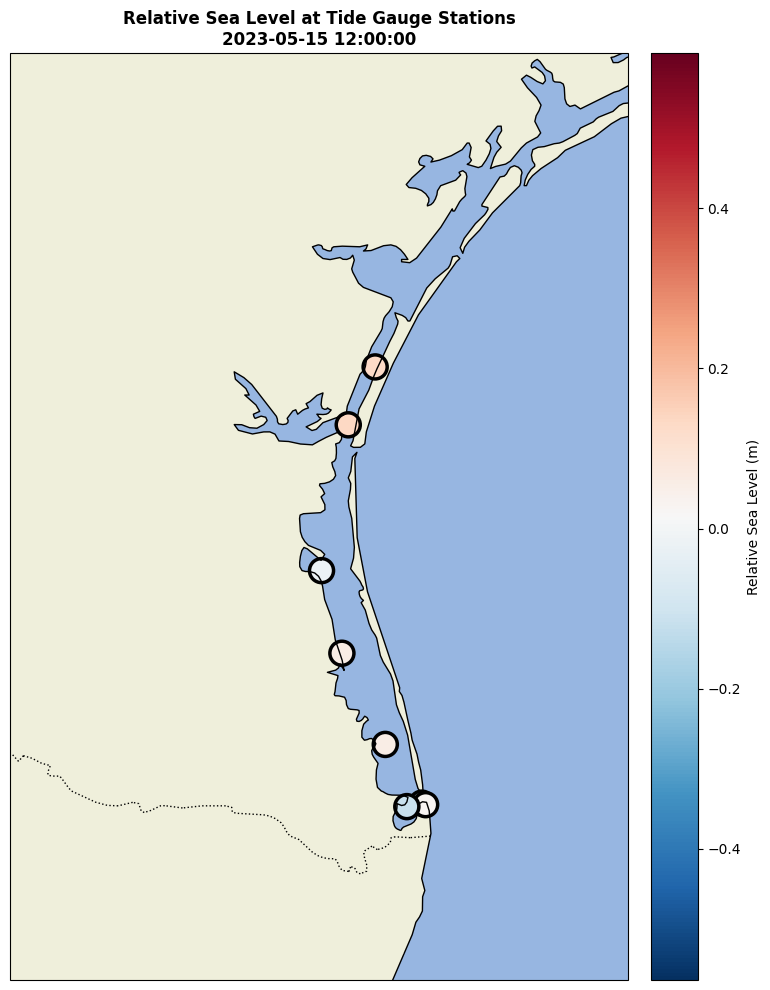

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Get time values and create figure
times = stations_data[list(stations_data.keys())[0]]['time'].values

# Get min and max values for colormap normalization
all_rel_sl = []
for ds in stations_data.values():
    all_rel_sl.extend(ds['rel_sea_level'].values)
vmin, vmax = np.nanmin(all_rel_sl), np.nanmax(all_rel_sl)
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdBu_r

# Create ScalarMappable for colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)

# Create output directory for frames
os.makedirs('figures/frames', exist_ok=True)

# Loop through each timestamp
for frame in range(len(times)):
    fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN, color='white')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([-98.5, -96.5, 25.5, 28.5])

    lons = []
    lats = []
    colors_list = []

    for station_name, ds in stations_data.items():
        lat = ds['latitude'].values
        lon = ds['longitude'].values
        rel_sl = ds['rel_sea_level'].values[frame]
        
        lons.append(lon)
        lats.append(lat)
        colors_list.append(rel_sl)

    scatter = ax.scatter(lons, lats, s=100, c=colors_list, cmap=cmap, norm=norm, 
                         edgecolors='black', linewidth=2.5, transform=ccrs.PlateCarree())

    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label('Relative Sea Level (m)', fontsize=10)

    time_str = pd.Timestamp(times[frame]).strftime('%Y-%m-%d %H:%M:%S')
    ax.set_title(f'Relative Sea Level at Tide Gauge Stations\n{time_str}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'figures/frames/relative_sea_level_{frame:04d}.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    if (frame + 1) % 100 == 0:
        print(f"Saved frame {frame + 1}/{len(times)}")

print(f"All {len(times)} frames saved to figures/frames/")
